<a href="https://colab.research.google.com/github/rhyhyr/Computer_vision/blob/main/dlshfl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

2026_dau_cv_path = kagglehub.competition_download('2026-DAU-CV')

print('Data source import complete.')


# **GPU 스펙 확인**

In [ ]:
!nvidia-smi

Tue Apr 28 14:18:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             28W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **라이브러리추가**

In [ ]:
import os
import random
import cv2

# Tensorflow 관련 디버그 및 경고 메시지 비활성화 (삭제 금지)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
import tensorflow.image as tfi
from tensorflow.keras import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image, ImageDraw
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# **폴더 경로 설정**

In [ ]:
data_path = '/kaggle/input/competitions/2026-DAU-CV'

# **재구현 세팅**

In [ ]:
def init_seeds(seed):
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    tf.config.experimental.enable_op_determinism()
    np.random.seed(seed)
    random.seed(seed)

In [ ]:
init_seeds(2026)

# **데이터 로드**

In [ ]:
train_image_path = os.path.join(data_path, 'train/images')
train_label_path = os.path.join(data_path, 'train/masks')
test_image_path = os.path.join(data_path, 'test/images')

output_path = '/kaggle/working'

In [ ]:
train_images = os.listdir(train_image_path)
train_images = [os.path.join(train_image_path, x) for x in train_images]
train_labels = os.listdir(train_label_path)
train_labels = [os.path.join(train_label_path, x) for x in train_labels]

train_images.sort(), train_labels.sort()

test_images = os.listdir(test_image_path)
test_images = [os.path.join(test_image_path, x) for x in test_images]

test_images.sort()

# **이미지 시각화**

sample image size : (512, 512), sample label size : (512, 512)


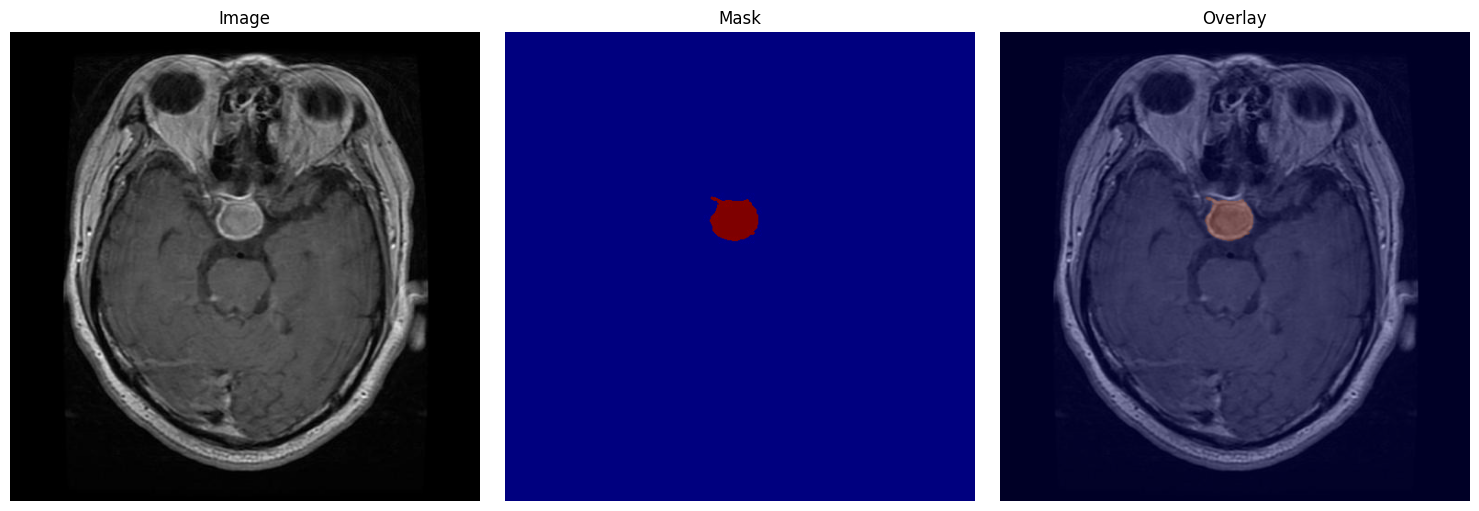

In [ ]:
sample_img = Image.open(train_images[0]).convert("RGB")
sample_label = Image.open(train_labels[0]).convert("L")

print(f'sample image size : {sample_img.size}, sample label size : {sample_label.size}')

img_np = np.array(sample_img)
label_np = np.array(sample_label)

label_color = cm.jet(label_np / 255.0)[:, :, :3]

overlay = (0.7 * img_np / 255.0 + 0.3 * label_color)
overlay = np.clip(overlay, 0, 1)

fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(label_color)
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# **데이터 전처리**

In [ ]:
def build_train_dataset(image_paths, mask_paths, img_height=256, img_width=256):
    X, y = [], []

    for img_path, mask_path in tqdm(zip(image_paths, mask_paths), total=len(image_paths)):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_width, img_height))
        img = img.astype(np.float32) / 255.0
        X.append(img)


        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_width, img_height))
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)
        y.append(mask)

    X = np.stack(X, axis=0)
    y = np.stack(y, axis=0)
    print(f"✅ Dataset loaded: X={X.shape}, y={y.shape}")
    return X, y


def build_test_dataset(image_paths, img_height=256, img_width=256):
    X = []
    for img_path in tqdm(image_paths):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_width, img_height))
        img = img.astype(np.float32) / 255.0
        X.append(img)

    X = np.stack(X, axis=0)
    print(f"✅ Test dataset loaded: X={X.shape}")
    return X

In [ ]:
img_height, img_width = 256, 256
train_X, train_y = build_train_dataset(train_images, train_labels, img_height = img_height, img_width = img_width)
test_X = build_test_dataset(test_images, img_height = img_height, img_width = img_width)

100%|██████████| 1311/1311 [00:18<00:00, 70.26it/s]


✅ Dataset loaded: X=(1311, 256, 256, 3), y=(1311, 256, 256, 1)


100%|██████████| 266/266 [00:02<00:00, 125.36it/s]


✅ Test dataset loaded: X=(266, 256, 256, 3)


In [ ]:
# plt.imshow(train_y[0]) # 인덱스 번호를 바꾸면 다른 학습 mask 확인 가능 (필요시 주석 제거)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),  # 좌우/상하 반전
    layers.RandomRotation(0.1),                    # 회전
    layers.RandomZoom(0.1),                        # 확대/축소
    layers.RandomBrightness(factor=0.1),           # 밝기 조정
], name="data_augmentation")

I0000 00:00:1777385951.811614      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# **모델 정의**

In [ ]:
def build_model(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # 데이터 증강 적용 시
    #x = data_augmentation(inputs)

    # 인코더 (Encoder)
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        return x

    e1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(e1)

    e2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(e2)

    e3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D((2, 2))(e3)

    # bottleneck
    b = conv_block(p3, 512)

    # 디코더 (Decoder)
    def up_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
        return x

    d3 = up_block(b, e3, 256)
    d2 = up_block(d3, e2, 128)
    d1 = up_block(d2, e1, 64)

    # 출력 레이어
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)

    model = models.Model(inputs, outputs, name="U-Net")
    return model

# **손실 함수 정의**

In [ ]:
def dice_coefficient(y_true, y_pred, threshold=0.5):
    y_pred = tf.cast(y_pred > threshold, tf.float32)

    smooth = 1e-5
    intersection = tf.reduce_sum(y_pred * y_true, axis=[1,2,3])
    union = tf.reduce_sum(y_pred, axis=[1,2,3]) + tf.reduce_sum(y_true, axis=[1,2,3])

    dice = (2. * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(dice)

def iou_coefficient(y_true, y_pred, threshold=0.5, smooth=1e-5):
    y_pred = tf.cast(y_pred > threshold, tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3]) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return tf.reduce_mean(iou)

# **모델 생성 및 컴파일**

In [ ]:
model = build_model(input_shape=(256, 256, 3))

# lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
#     initial_learning_rate=1e-3,
#     first_decay_steps=50,
#     t_mul=1.0,
#     m_mul=1.0,
#     alpha=1e-6 / 1e-4
# )

# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, weight_decay=1e-4)

loss_func = tf.keras.losses.BinaryCrossentropy(from_logits=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_func,
    metrics=[dice_coefficient, iou_coefficient]
)

model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    524,544 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │    131,200 │ conv2d_9[0][0]  

 Total params: 7,697,345 (29.36 MB)

 Trainable params: 7,697,345 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

# **모델 학습**

In [ ]:
history = model.fit(
    train_X, train_y,
    validation_split=0.1,
    batch_size=4,
    epochs=5
)

Epoch 1/5


I0000 00:00:1777385961.584650     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
W0000 00:00:1777385962.622565     135 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 4
in_depths: 256
out_depths: 512
in: 64
in: 64
data_format: 1
filter: 2
filter: 2
filter: 256
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KHz clock, 715000KHz mem clock, 4194304B L2$"
version: 3

W0000 00:00:1777385962.937197     135 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 4
in_depths: 128
out_depths: 256
in: 128
in: 128
data_format: 1
filter: 2
filter: 2
filter: 128
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KH

295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - dice_coefficient: 0.0027 - iou_coefficient: 0.0014 - loss: 0.2598

W0000 00:00:1777385995.279746     138 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 3
in_depths: 256
out_depths: 512
in: 64
in: 64
data_format: 1
filter: 2
filter: 2
filter: 256
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KHz clock, 715000KHz mem clock, 4194304B L2$"
version: 3

W0000 00:00:1777385995.300247     138 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 3
in_depths: 128
out_depths: 256
in: 128
in: 128
data_format: 1
filter: 2
filter: 2
filter: 128
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KHz clock, 715000KHz mem clock, 4194304B L2$"
version: 3

W0000 00:00:1777385995.318

295/295 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - dice_coefficient: 0.0026 - iou_coefficient: 0.0014 - loss: 0.2594 - val_dice_coefficient: 1.8524e-08 - val_iou_coefficient: 1.8524e-08 - val_loss: 0.0633
Epoch 2/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 33s 112ms/step - dice_coefficient: 1.8042e-08 - iou_coefficient: 1.8042e-08 - loss: 0.0655 - val_dice_coefficient: 1.8524e-08 - val_iou_coefficient: 1.8524e-08 - val_loss: 0.0584
Epoch 3/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 33s 112ms/step - dice_coefficient: 1.8042e-08 - iou_coefficient: 1.8042e-08 - loss: 0.0621 - val_dice_coefficient: 1.8524e-08 - val_iou_coefficient: 1.8524e-08 - val_loss: 0.0533
Epoch 4/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 33s 112ms/step - dice_coefficient: 9.4153e-04 - iou_coefficient: 6.1682e-04 - loss: 0.0577 - val_dice_coefficient: 0.1688 - val_iou_coefficient: 0.1119 - val_loss: 0.0464
Epoch 5/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 33s 113ms/step - dice_coefficient: 0.2247 - iou_coefficient: 0.1610 - loss: 0.0514 - val_dice_coefficient: 0.5245 -

In [ ]:
#예측값 확인 예시 (필요시 주석 제거)
# pred = model.predict(train_X[:5])
# print(pred.min(), pred.max())
# plt.hist(pred.flatten(), bins=50)
# plt.title("Predicted Probability Distribution")
# plt.xlabel("Predicted Value")
# plt.ylabel("Pixel Count")
# plt.show()

# **모델 예측**

In [ ]:
pred = model.predict(test_X, batch_size=8)

 1/34 ━━━━━━━━━━━━━━━━━━━━ 19s 578ms/step

W0000 00:00:1777386131.553176     136 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 8
in_depths: 256
out_depths: 512
in: 64
in: 64
data_format: 1
filter: 2
filter: 2
filter: 256
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KHz clock, 715000KHz mem clock, 4194304B L2$"
version: 3

W0000 00:00:1777386131.590599     136 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 8
in_depths: 128
out_depths: 256
in: 128
in: 128
data_format: 1
filter: 2
filter: 2
filter: 128
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KHz clock, 715000KHz mem clock, 4194304B L2$"
version: 3

W0000 00:00:1777386131.623

34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step


W0000 00:00:1777386134.817282     137 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 2
in_depths: 256
out_depths: 512
in: 64
in: 64
data_format: 1
filter: 2
filter: 2
filter: 256
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KHz clock, 715000KHz mem clock, 4194304B L2$"
version: 3

W0000 00:00:1777386134.834555     137 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 2
in_depths: 128
out_depths: 256
in: 128
in: 128
data_format: 1
filter: 2
filter: 2
filter: 128
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.0 with 17059545088B RAM, 56 cores, 1328500KHz clock, 715000KHz mem clock, 4194304B L2$"
version: 3

W0000 00:00:1777386134.850

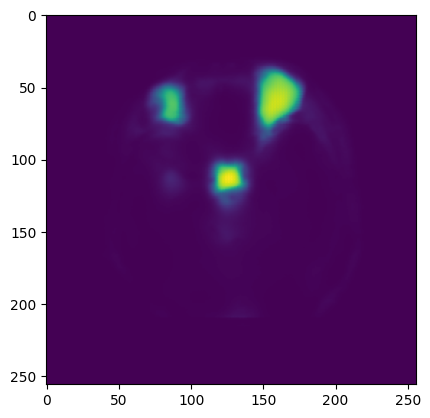

In [ ]:
# 예측결과 확인 (필요시 주석 제거)
plt.imshow(pred[0])

# **Run-Length Encoding 및 예측 결과 저장**

In [ ]:
output_path = '/kaggle/working'
result_path = os.path.join(output_path, 'results')
os.makedirs(result_path, exist_ok=True)

In [ ]:
# 수정X
def rle_encode(mask):
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    if len(runs) % 2 != 0:
        runs = np.append(runs, len(pixels) - 1)
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

In [ ]:
# 수정X

THRESHOLD = 0.5

rle_list = []

for i in range(pred.shape[0]):
    prob = pred[i, :, :, 0]
    mask = (prob > THRESHOLD).astype(np.uint8)

    rle = rle_encode(mask)
    rle_list.append(rle)

    mask_img = mask * 255
    cv2.imwrite(os.path.join(result_path, f"{i+1:04d}.jpg"), mask_img)

# **제출 CSV 파일 저장**

In [ ]:
submission = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))

In [ ]:
submission['EncodedPixels'] = rle_list
submission.head()

,Image_Label,EncodedPixels
0,0001.jpg,21048 4 21059 5 21303 18 21558 19 21814 20 220...
1,0002.jpg,31583 2 31829 13 32083 15 32337 17 32593 17 32...
2,0003.jpg,
3,0004.jpg,30353 1 30604 10 30857 18 31112 21 31367 22 31...
4,0005.jpg,22068 2 22319 10 22573 15 22826 21 23080 25 23...


In [ ]:
submission.to_csv('sample_submission.csv', index=False)

In [ ]:
import shutil
shutil.make_archive('label', 'zip', result_path)

'/kaggle/working/label.zip'

In [ ]:
shutil.rmtree(result_path)